# Google Gemini Models

https://ai.google.dev/pricing#1_5flash

Gemini provide limited free-tier pricing for the certain models with rate limits.

Examples
- Gemini 1.5 Flash: 15 RPM (requests per minute)
- Gemini 1.5 Pro: 2 RPM (requests per minute)
- Text Embedding 004: 1,500 RPM (requests per minute)

# Retrieval Aumented Generation (RAG) architecture

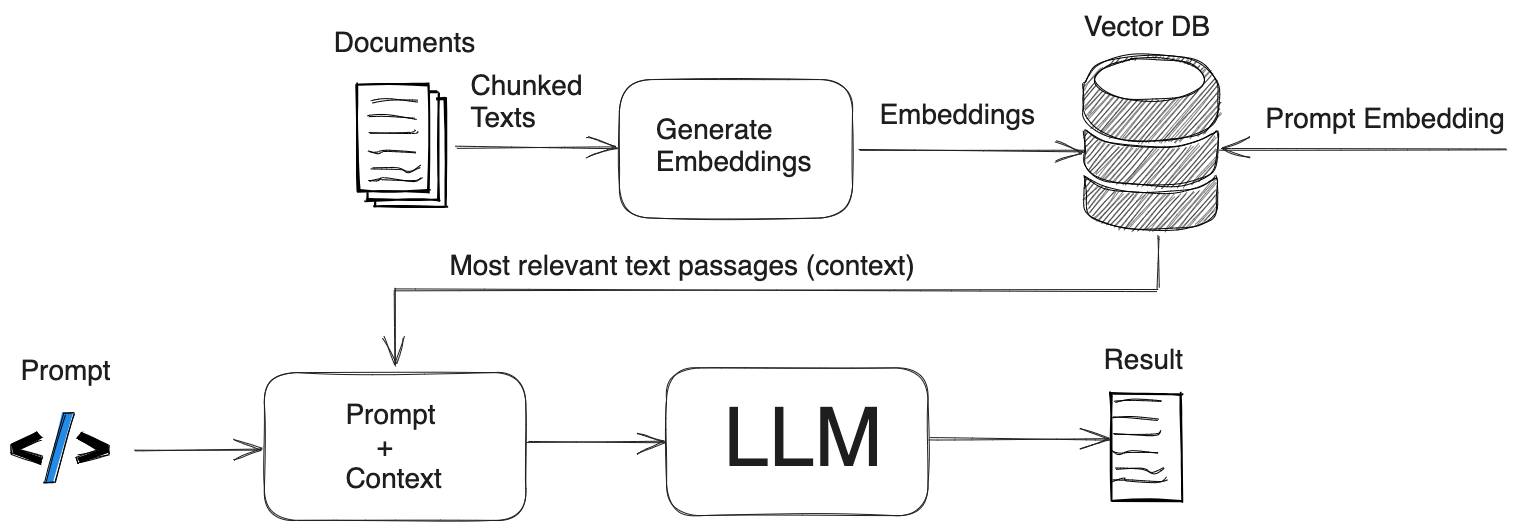

# Making Chatbot More Conversational

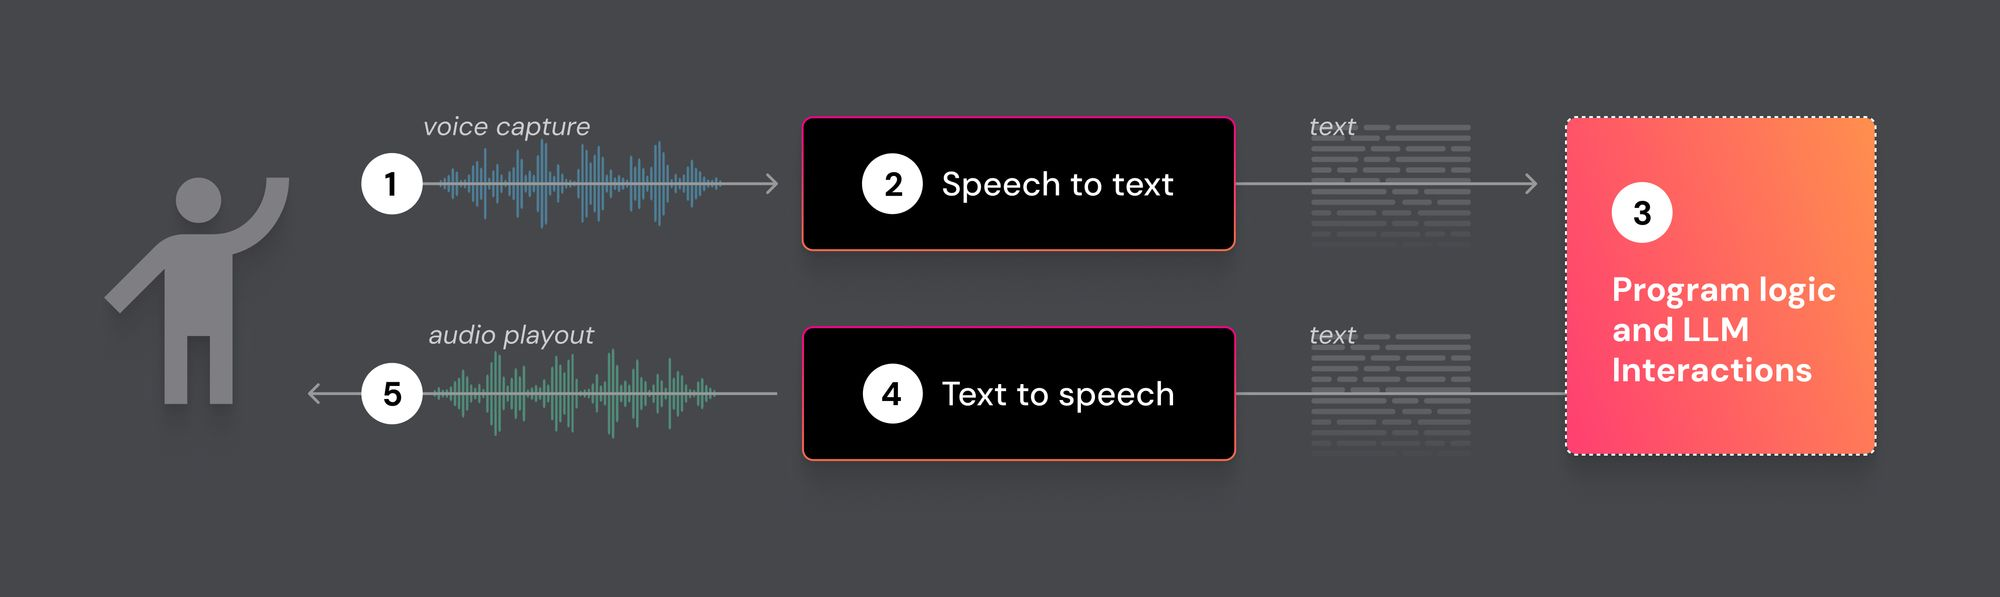

# Agents with Tools

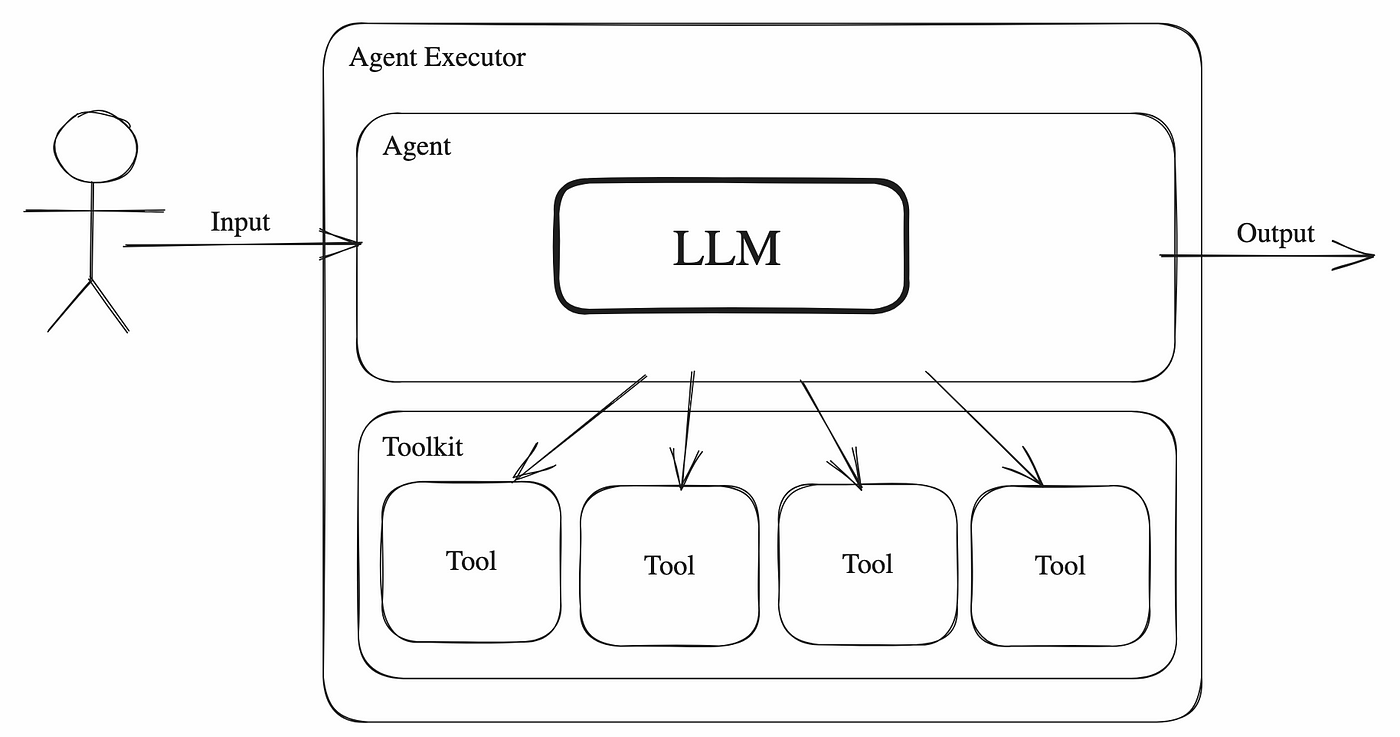

In [2]:
!pip install -q gradio
!pip install -q langchain-google-genai
!pip install -q langchain langchain_community jq
!pip install -q chromadb  # vector db
!pip install -q torchaudio omegaconf  # for text to speech

## Import Libraries

In [3]:
import google.generativeai as genai
import gradio as gr
import time
import requests  # to make API calls to external services
import os
import numpy as np
from datetime import datetime

# langchain libraries
from langchain_google_genai import ChatGoogleGenerativeAI, GoogleGenerativeAIEmbeddings

from langchain import PromptTemplate
from langchain import hub
from langchain.docstore.document import Document
from langchain_community.document_loaders import JSONLoader
from langchain.schema import StrOutputParser
from langchain.schema.prompt_template import format_document
from langchain.schema.runnable import RunnablePassthrough
from langchain.vectorstores import Chroma

# Agents with tools
import re

# Text-to-Speech (TTS)
import torch
from IPython.display import Audio, display

# Speech-to-Text (STT)
import io
import base64
from transformers import pipeline  # huggingface

In [4]:
# Import API KEY
from google.colab import userdata
gemini_api_key = userdata.get('GOOGLE_API_KEY')
# genai.configure(api_key=gemini_api_key)

os.environ['GOOGLE_API_KEY'] = gemini_api_key

## Retriever

###### Read JSON file

In [5]:
json_loader = JSONLoader(
    file_path="/content/intents.json",
    jq_schema=".intents[]",
    text_content=False,
)
docs = json_loader.load()
print(len(docs))
docs

21


[Document(metadata={'source': '/content/intents.json', 'seq_num': 1}, page_content='{"tag": "greeting", "patterns": ["Hi", "Hey", "Hello", "Good morning", "Good afternoon", "Good evening", "Hey Siri", "Is anyone there?", "Hello there"], "responses": ["Hello", "Hi there", "Hi, how can I help you today?", "Good morning to you", "Good afternoon", "Good evening"]}'),
 Document(metadata={'source': '/content/intents.json', 'seq_num': 2}, page_content='{"tag": "goodbye", "patterns": ["Bye", "See you later", "Goodbye", "See ya", "Have a good one", "Take care", "Thanks, bye"], "responses": ["See you later", "Have a nice day", "Bye! Come back again", "Goodbye"]}'),
 Document(metadata={'source': '/content/intents.json', 'seq_num': 3}, page_content='{"tag": "thanks", "patterns": ["Thanks", "Thank you", "That\'s helpful", "Thanks for the help", "I appreciate it", "You\'re the best"], "responses": ["Happy to help!", "Any time!", "My pleasure", "You\'re most welcome!"]}'),
 Document(metadata={'source

###### Create Embeddings of the JSON data

In [6]:
gemini_embeddings = GoogleGenerativeAIEmbeddings(model="models/text-embedding-004")

###### Store the Embeddings in Chroma's vector store

In [7]:
vectorstore = Chroma.from_documents(
    documents=docs,
    embedding=gemini_embeddings,
    persist_directory="./chroma_db",
)

###### Create a Retriever from the Chroma vector store

In [8]:
# Load from Disk
vectorstore_disk = Chroma(
    persist_directory="./chroma_db",
    embedding_function=gemini_embeddings,
)

retriever = vectorstore_disk.as_retriever(search_kwargs={"k": 1})

relevant_doc = retriever.get_relevant_documents(query="who are you")
print(len(relevant_doc))
print(relevant_doc)

relevant_doc2 = retriever.get_relevant_documents(query="what is the time")
print(len(relevant_doc2))
print(relevant_doc2)

relevant_doc3 = retriever.get_relevant_documents(query="what is the date today")
print(len(relevant_doc3))
print(relevant_doc3)

<ipython-input-8-e5cd9112add1>:2: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-chroma package and should be used instead. To use it run `pip install -U :class:`~langchain-chroma` and import as `from :class:`~langchain_chroma import Chroma``.
  vectorstore_disk = Chroma(
<ipython-input-8-e5cd9112add1>:9: LangChainDeprecationWarning: The method `BaseRetriever.get_relevant_documents` was deprecated in langchain-core 0.1.46 and will be removed in 1.0. Use :meth:`~invoke` instead.
  relevant_doc = retriever.get_relevant_documents(query="who are you")


1
[Document(metadata={'seq_num': 4, 'source': '/content/intents.json'}, page_content='{"tag": "about", "patterns": ["Who are you?", "What are you?", "Who you are?", "What\'s your name?", "Tell me about yourself"], "responses": ["I\'m your personal assistant, here to help.", "I\'m designed to assist you with various tasks.", "You can ask me to do things like set reminders, play music, and answer your questions."]}')]
1
[Document(metadata={'seq_num': 9, 'source': '/content/intents.json'}, page_content='{"tag": "time", "patterns": ["What time is it?", "Do you have the time?", "Tell me the time", "What\'s the time?"], "responses": ["It\'s [current_time].", "The current time is [current_time]."]}')]
1
[Document(metadata={'seq_num': 10, 'source': '/content/intents.json'}, page_content='{"tag": "date", "patterns": ["What\'s the date today?", "What day is it today?", "Tell me the date", "What\'s the date"], "responses": ["Today is [current_date].", "It\'s [current_date]."]}')]


## Generator

###### Initialise Google Chat Model

In [9]:
# Model Configuration
model = genai.GenerativeModel("gemini-1.5-flash")

llm = ChatGoogleGenerativeAI(
    model="gemini-1.5-flash",
    temperature=0,  # no creativity allowed
)

###### Create Prompt Template

In [10]:
prompt_template = """
You are a personal virtual assistant. You are to assist the user with a variety of queries and tasks.
Use the following context to respond to the user's query.
If there are placeholder fields enclosed in square brackets, do not modify them.

Query: {query}
Context: {context}
Response:
"""

llm_prompt = PromptTemplate(
    input_variables=["query", "context"],
    template=prompt_template,
)

print(llm_prompt)

input_variables=['context', 'query'] input_types={} partial_variables={} template="\nYou are a personal virtual assistant. You are to assist the user with a variety of queries and tasks.\nUse the following context to respond to the user's query.\nIf there are placeholder fields enclosed in square brackets, do not modify them.\n\nQuery: {query}\nContext: {context}\nResponse:\n"


###### Create a stuff documents chain

In [11]:
def format_docs(docs):
  str_docs = "\n\n".join(doc.page_content for doc in docs)
  print(str_docs)
  return str_docs

rag_chain = (
    {"context": retriever | format_docs, "query": RunnablePassthrough()}
    | llm_prompt
    | llm
    | StrOutputParser()
)

###### Prompt the Model

In [12]:
response = rag_chain.invoke("hi!")
print(response)
time.sleep(5)

{"tag": "greeting", "patterns": ["Hi", "Hey", "Hello", "Good morning", "Good afternoon", "Good evening", "Hey Siri", "Is anyone there?", "Hello there"], "responses": ["Hello", "Hi there", "Hi, how can I help you today?", "Good morning to you", "Good afternoon", "Good evening"]}
Hi there


In [13]:
response = rag_chain.invoke("tell me about yourself")
print(response)
time.sleep(5)

{"tag": "about", "patterns": ["Who are you?", "What are you?", "Who you are?", "What's your name?", "Tell me about yourself"], "responses": ["I'm your personal assistant, here to help.", "I'm designed to assist you with various tasks.", "You can ask me to do things like set reminders, play music, and answer your questions."]}
I'm your personal assistant, here to help.  I'm designed to assist you with various tasks. You can ask me to do things like set reminders, play music, and answer your questions.


In [14]:
response = rag_chain.invoke("what is the time now?")
print(response)
time.sleep(5)

{"tag": "time", "patterns": ["What time is it?", "Do you have the time?", "Tell me the time", "What's the time?"], "responses": ["It's [current_time].", "The current time is [current_time]."]}
The current time is [current_time].


In [15]:
response = rag_chain.invoke("what is the date today")
print(response)
time.sleep(5)

{"tag": "date", "patterns": ["What's the date today?", "What day is it today?", "Tell me the date", "What's the date"], "responses": ["Today is [current_date].", "It's [current_date]."]}
Today is [current_date].


In [16]:
# Ask a question that is not found in the context
response = rag_chain.invoke("what is gemini?")
print(response)
time.sleep(5)

{"tag": "about", "patterns": ["Who are you?", "What are you?", "Who you are?", "What's your name?", "Tell me about yourself"], "responses": ["I'm your personal assistant, here to help.", "I'm designed to assist you with various tasks.", "You can ask me to do things like set reminders, play music, and answer your questions."]}
I'm sorry, I don't have any information about Gemini in my current context.  My knowledge is limited to the information provided to me.


###### Convert text to speech (TTS)

In [17]:
# download pre-trained model from torchhub

language = "en"
speaker = "lj_16khz"
device = torch.device("cpu")
tts_model, symbols, sample_rate, _, apply_tts = torch.hub.load(
    repo_or_dir='snakers4/silero-models',
    model='silero_tts',
    language=language,
    speaker=speaker
)

tts_model.to(device)

print(f"{sample_rate=}")
print(f"{symbols=}")

/usr/local/lib/python3.11/dist-packages/torch/hub.py:330: UserWarning: You are about to download and run code from an untrusted repository. In a future release, this won't be allowed. To add the repository to your trusted list, change the command to {calling_fn}(..., trust_repo=False) and a command prompt will appear asking for an explicit confirmation of trust, or load(..., trust_repo=True), which will assume that the prompt is to be answered with 'yes'. You can also use load(..., trust_repo='check') which will only prompt for confirmation if the repo is not already trusted. This will eventually be the default behaviour
  warnings.warn(
Downloading: "https://github.com/snakers4/silero-models/zipball/master" to /root/.cache/torch/hub/master.zip
100%|██████████| 136M/136M [00:06<00:00, 20.9MB/s]


sample_rate=16000
symbols='_~abcdefghijklmnopqrstuvwxyz .,!?…:;–'


In [18]:
response = rag_chain.invoke("tell me about yourself")
print(response)
time.sleep(5)

{"tag": "about", "patterns": ["Who are you?", "What are you?", "Who you are?", "What's your name?", "Tell me about yourself"], "responses": ["I'm your personal assistant, here to help.", "I'm designed to assist you with various tasks.", "You can ask me to do things like set reminders, play music, and answer your questions."]}
I'm your personal assistant, here to help.  I'm designed to assist you with various tasks. You can ask me to do things like set reminders, play music, and answer your questions.


In [19]:
audio = apply_tts(texts=response,
                  model=tts_model,
                  sample_rate=sample_rate,
                  symbols=symbols,
                  device=device)

display(Audio(audio, autoplay=True, rate=sample_rate))

/root/.cache/torch/hub/snakers4_silero-models_master/src/silero/tts_utils.py:27: UserWarning: Text string is longer than 140 symbols.
  warnings.warn('Text string is longer than 140 symbols.')


###### Speech to Text (STT)

In [20]:
# speech to text model
transcriber = pipeline("automatic-speech-recognition", model="openai/whisper-base.en")

config.json:   0%|          | 0.00/1.94k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/290M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/1.53k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/805 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

...

normalizer.json:   0%|          | 0.00/52.7k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/34.6k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/1.83k [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/185k [00:00<?, ?B/s]

Device set to use cpu


## Agents with Tools

- Intelligent Agents
- ReAct Agents

###### Call external API for specific task

In [21]:
def get_time_from_time_api():
    url_str = "https://timeapi.io/api/time/current/zone?timeZone=Asia%2FSingapore"
    try:
        response = requests.get(url_str, timeout=5)  # Add a timeout
        response.raise_for_status()  # Raise exception for bad status codes
        time_data = response.json()
        current_time = time_data["time"]
        print(f"The current time in Singapore is: {current_time}")
        return current_time
    except requests.exceptions.RequestException as e:
        print(f"Error: Unable to retrieve time from API: {e}")
        print("Using local time as fallback.")
        return datetime.now().strftime("%H:%M:%S")  # Fallback to local time in HH:MM:SS format
    except (KeyError, TypeError) as e: # Handle potential JSON parsing errors
        print(f"Error: Unexpected data format from API: {e}")
        print("Using local time as fallback.")
        return datetime.now().strftime("%H:%M:%S") # Fallback to local time

get_time_from_time_api()

The current time in Singapore is: 02:00


'02:00'

In [22]:
def get_date_from_time_api():
  url_str = "https://timeapi.io/api/time/current/zone?timeZone=Asia%2FSingapore"
  try:
    response = requests.get(url_str, timeout=5) # Add a timeout for robustness
    response.raise_for_status()  # Raise an exception for bad status codes (4xx or 5xx)
    time_data = response.json()
    current_date = time_data["dateTime"].split("T")[0]
    print(f"The current date in Singapore is: {current_date}")
    return current_date
  except requests.exceptions.RequestException as e:
    print(f"Error: Unable to retrieve date from API: {e}")
    print("Using local time as fallback.")
    return datetime.now().strftime("%Y-%m-%d") # Fallback to local time

get_date_from_time_api()

The current date in Singapore is: 2025-02-02


'2025-02-02'

###### Identify and invoke the tools

In [23]:
def replace_placeholders(text):
  def replace_match(match):
    placeholder = match.group(1)
    if placeholder == "current_time":
      return get_time_from_time_api()
    elif placeholder == "current_date":
      return get_date_from_time_api()
    else:
      return match.group(0)  # Leave unmatched placeholders as they are
  return re.sub(r"\[(.*?)\]", replace_match, text)  # Use regex to find placeholders

In [24]:
genai.configure(api_key=gemini_api_key)
content = model.generate_content("convert this time or date into english words: 2025-01-30")
print(content)
print(content.text)
time.sleep(5)

response:
GenerateContentResponse(
    done=True,
    iterator=None,
    result=protos.GenerateContentResponse({
      "candidates": [
        {
          "content": {
            "parts": [
              {
                "text": "January 30th, 2025\n"
              }
            ],
            "role": "model"
          },
          "finish_reason": "STOP",
          "avg_logprobs": -0.00023813118847707906
        }
      ],
      "usage_metadata": {
        "prompt_token_count": 21,
        "candidates_token_count": 12,
        "total_token_count": 33
      },
      "model_version": "gemini-1.5-flash"
    }),
)
January 30th, 2025



## Gradio as UI Chat interface

In [ ]:
def play_tts_audio(text):
    audio_tensor = apply_tts(texts=text,
                  model=tts_model,
                  sample_rate=sample_rate,
                  symbols=symbols,
                  device=device)

    print(f"Type of audio_tensor (IMMEDIATELY): {type(audio_tensor)}")

    modified_audio_tensor = audio_tensor  # Keep a copy of the original

    if isinstance(audio_tensor, list):
        print(f"audio_tensor is a list. Length: {len(audio_tensor)}")

        if all(isinstance(item, torch.Tensor) for item in audio_tensor):
            print("It is a list of tensors")
            if len(audio_tensor) == 1:
                audio_tensor = audio_tensor[0]  # Extract the tensor
                modified_audio_tensor = audio_tensor  # Update the modified tensor
                print(f"Extracted tensor from the list. Type: {type(audio_tensor)}")
            else:
                audio_tensor = torch.cat(audio_tensor, dim=0)
                modified_audio_tensor = audio_tensor  # Update the modified tensor
                print(f"Concatenated tensors. Type: {type(audio_tensor)}")


    # From here on, audio_tensor should be a single tensor or numpy array

    if isinstance(modified_audio_tensor, torch.Tensor):  # Use the modified tensor!
        audio_np = modified_audio_tensor.cpu().numpy()  # Use the modified tensor!
        print("modified_audio_tensor is a Tensor")
    elif isinstance(modified_audio_tensor, np.ndarray):  # Use the modified tensor!
        audio_np = modified_audio_tensor  # Use the modified tensor!
        print("modified_audio_tensor is a np.ndarray")

    display(Audio(modified_audio_tensor, autoplay=True, rate=sample_rate))  # Display the modified tensor!

    print(f"{audio_np.dtype=}")

    # Force contiguity and float32
    audio_float = np.ascontiguousarray(audio_np.astype(np.float32))

    if audio_float.size == 0:
        print("ERROR: audio_float is EMPTY!")

    return sample_rate, audio_float  # Return for Gradio


#iface = gr.Interface(
#    fn=play_tts_audio,
#    inputs=gr.Textbox(lines=2, placeholder="Enter text for TTS"),
#    outputs=gr.Audio(),  # Correct for Gradio 3+
#    title="TTS Audio Player"
#)

#iface.launch(debug=True)

In [25]:
def gradio_respond(message, chat_history, audio_in):
  # Text input
  if message:
    # user_input = message
    # message = "" # Clear the textbox after submit
    pass
  # Try STT
  elif audio_in is not None:
    sample_rate_in, audio_data_in = audio_in  # Unpack the tuple
    print("Sample Rate:", sample_rate_in)
    print("Audio Data Shape:", audio_data_in.shape) # Print Shape

    # Convert to mono if stereo
    if audio_data_in.ndim > 1:
        audio_data_in = audio_data_in.mean(axis=1)

    audio_data_in = audio_data_in.astype(np.float32)
    audio_data_in /= np.max(np.abs(audio_data_in))

    microphone_speech_to_text = transcriber({"sampling_rate": sample_rate_in, "raw": audio_data_in})["text"]
    print(f"{microphone_speech_to_text=}")
    if len(microphone_speech_to_text) > 0:
      message = microphone_speech_to_text

  print(f"{message=}")
  bot_message = ''
  audio_np = None
  if message is not None and len(message) > 0:
    initial_bot_message = rag_chain.invoke(message)
    print(f"{initial_bot_message=}")
    bot_message = replace_placeholders(initial_bot_message) # Process and replace placeholders
    print(f"{bot_message=}")
    audio_message = bot_message

    # TTS generation
    if len(initial_bot_message) != len(bot_message):
      content = model.generate_content("Return the entire sentence unchanged, except replace the time (in 24 hr format) or date into english words: " + bot_message)
      print(f"{content.text=}")
      audio_message = content.text

    audio_tensor = apply_tts(texts=audio_message,
                      model=tts_model,
                      sample_rate=sample_rate,
                      symbols=symbols,
                      device=device)

    if isinstance(audio_tensor, list):
      if all(isinstance(item, torch.Tensor) for item in audio_tensor):
        if len(audio_tensor) == 1:
          audio_tensor = audio_tensor[0]
        elif all(isinstance(item, np.ndarray) for item in audio_tensor):
          audio_tensor = np.concatenate(audio_tensor, axis=0)

      if isinstance(audio_tensor, torch.Tensor):
        audio_np = audio_tensor.cpu().numpy().astype(np.float32)
      elif isinstance(audio_tensor, np.ndarray):
        audio_np = audio_tensor.astype(np.float32)

      audio_np = np.ascontiguousarray(audio_np) # Force contiguity

  chat_history.append((message, ""))  # Update Chat History
  if audio_np is None:
    yield "", chat_history, audio_np
  else:
    yield "", chat_history, (sample_rate, audio_np)

  # stream the response char by char
  for i in range(len(bot_message)):
    time.sleep(0.05)
    updated_bot_message = bot_message[:i+1]
    chat_history[-1] = (message, updated_bot_message)
    if audio_np is None:
      yield "", chat_history, audio_np
    else:
      yield "", chat_history, (sample_rate, audio_np)


In [26]:
# Gradio provides Chatbot and ChatInterface
# Use Chatbot if you want fine-grained customisation
# Use ChatInterface if you want out of the box features

with gr.Blocks(title="My Gemini Personal Virtual Assistant") as demo:
  chatbot = gr.Chatbot()
  with gr.Row():
    msg = gr.Textbox()
    audio_in = gr.Audio(sources="microphone")
  clear = gr.Button("Clear")
  audio_out = gr.Audio(type="numpy")

  msg.submit(
      gradio_respond,
      inputs=[msg, chatbot, audio_in],
      outputs=[msg, chatbot, audio_out],
  )
  # Submit when microphone input changes
  audio_in.change(
      gradio_respond,
      inputs=[msg, chatbot, audio_in],
      outputs=[msg, chatbot, audio_out],
  )
  clear.click(lambda: None, None, chatbot, queue=False)


demo.launch(debug=True)

/usr/local/lib/python3.11/dist-packages/gradio/components/chatbot.py:282: UserWarning: You have not specified a value for the `type` parameter. Defaulting to the 'tuples' format for chatbot messages, but this is deprecated and will be removed in a future version of Gradio. Please set type='messages' instead, which uses openai-style dictionaries with 'role' and 'content' keys.
  warnings.warn(


Running Gradio in a Colab notebook requires sharing enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://b35d544932d2ba3e1b.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


message='hi there'
{"tag": "greeting", "patterns": ["Hi", "Hey", "Hello", "Good morning", "Good afternoon", "Good evening", "Hey Siri", "Is anyone there?", "Hello there"], "responses": ["Hello", "Hi there", "Hi, how can I help you today?", "Good morning to you", "Good afternoon", "Good evening"]}
initial_bot_message='Hi there'
bot_message='Hi there'


/usr/local/lib/python3.11/dist-packages/gradio/processing_utils.py:741: UserWarning: Trying to convert audio automatically from float32 to 16-bit int format.
  warnings.warn(warning.format(data.dtype))


message='who are you'
{"tag": "about", "patterns": ["Who are you?", "What are you?", "Who you are?", "What's your name?", "Tell me about yourself"], "responses": ["I'm your personal assistant, here to help.", "I'm designed to assist you with various tasks.", "You can ask me to do things like set reminders, play music, and answer your questions."]}
initial_bot_message="I'm your personal assistant, here to help."
bot_message="I'm your personal assistant, here to help."


...

message=''
Sample Rate: 44100
Audio Data Shape: (158760,)


/usr/local/lib/python3.11/dist-packages/transformers/models/whisper/generation_whisper.py:512: FutureWarning: The input name `inputs` is deprecated. Please make sure to use `input_features` instead.
  warnings.warn(


microphone_speech_to_text=' Hi Siri, tell me the date now.'
message=' Hi Siri, tell me the date now.'
{"tag": "date", "patterns": ["What's the date today?", "What day is it today?", "Tell me the date", "What's the date"], "responses": ["Today is [current_date].", "It's [current_date]."]}
initial_bot_message='Today is [current_date].'
The current date in Singapore is: 2025-02-02
bot_message='Today is 2025-02-02.'
content.text='Today is February second, twenty twenty-five.\n'


/usr/local/lib/python3.11/dist-packages/gradio/processing_utils.py:741: UserWarning: Trying to convert audio automatically from float32 to 16-bit int format.
  warnings.warn(warning.format(data.dtype))


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://b35d544932d2ba3e1b.gradio.live
